c:\Users\bilbo\OneDrive\Pulpit\pł\2sem\UN\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


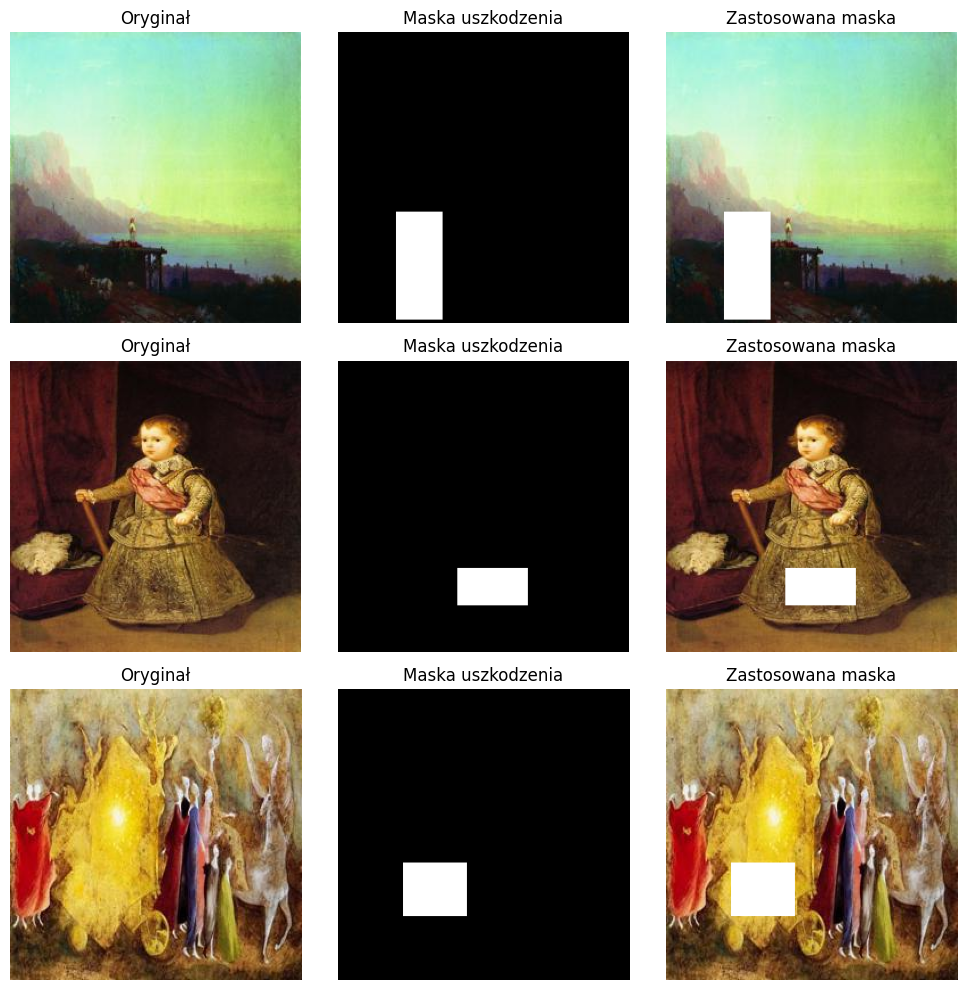

In [1]:
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
import random
from datasets import load_dataset

# 1. Wczytanie zbioru WikiArt z Hugging Face
dataset = load_dataset("Artificio/WikiArt_Full", split="train[:1%]")  # mała próbka dla szybkości

transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor()
])

def get_random_image():
    sample = random.choice(dataset)
    img = sample['image'].convert('RGB')
    return transform(img)

# 2. Funkcja do tworzenia maski prostokątnej
def generate_random_mask(shape, max_mask_fraction=0.2):
    _, h, w = shape
    mask = torch.zeros((1, h, w))
    mask_h = random.randint(int(h*0.1), int(h*max_mask_fraction*2))
    mask_w = random.randint(int(w*0.1), int(w*max_mask_fraction*2))

    top = random.randint(0, h - mask_h)
    left = random.randint(0, w - mask_w)

    mask[:, top:top+mask_h, left:left+mask_w] = 1.0
    return mask

# 3. Funkcja nakładająca maskę na obraz
def apply_mask(img, mask):
    damaged = img.clone()
    damaged = damaged * (1 - mask) + mask  # 1 to białe uszkodzenie
    return damaged

# 4. Losujemy kilka obrazów i pokazujemy maski + efekt
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(3):
    img = get_random_image()
    mask = generate_random_mask(img.shape)
    damaged = apply_mask(img, mask)

    axes[i, 0].imshow(img.permute(1, 2, 0))
    axes[i, 0].set_title('Oryginał')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask.squeeze(), cmap='gray')
    axes[i, 1].set_title('Maska uszkodzenia')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(damaged.permute(1, 2, 0))
    axes[i, 2].set_title('Zastosowana maska')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()


Wczytywanie małej próbki WikiArt (może chwilę potrwać)...


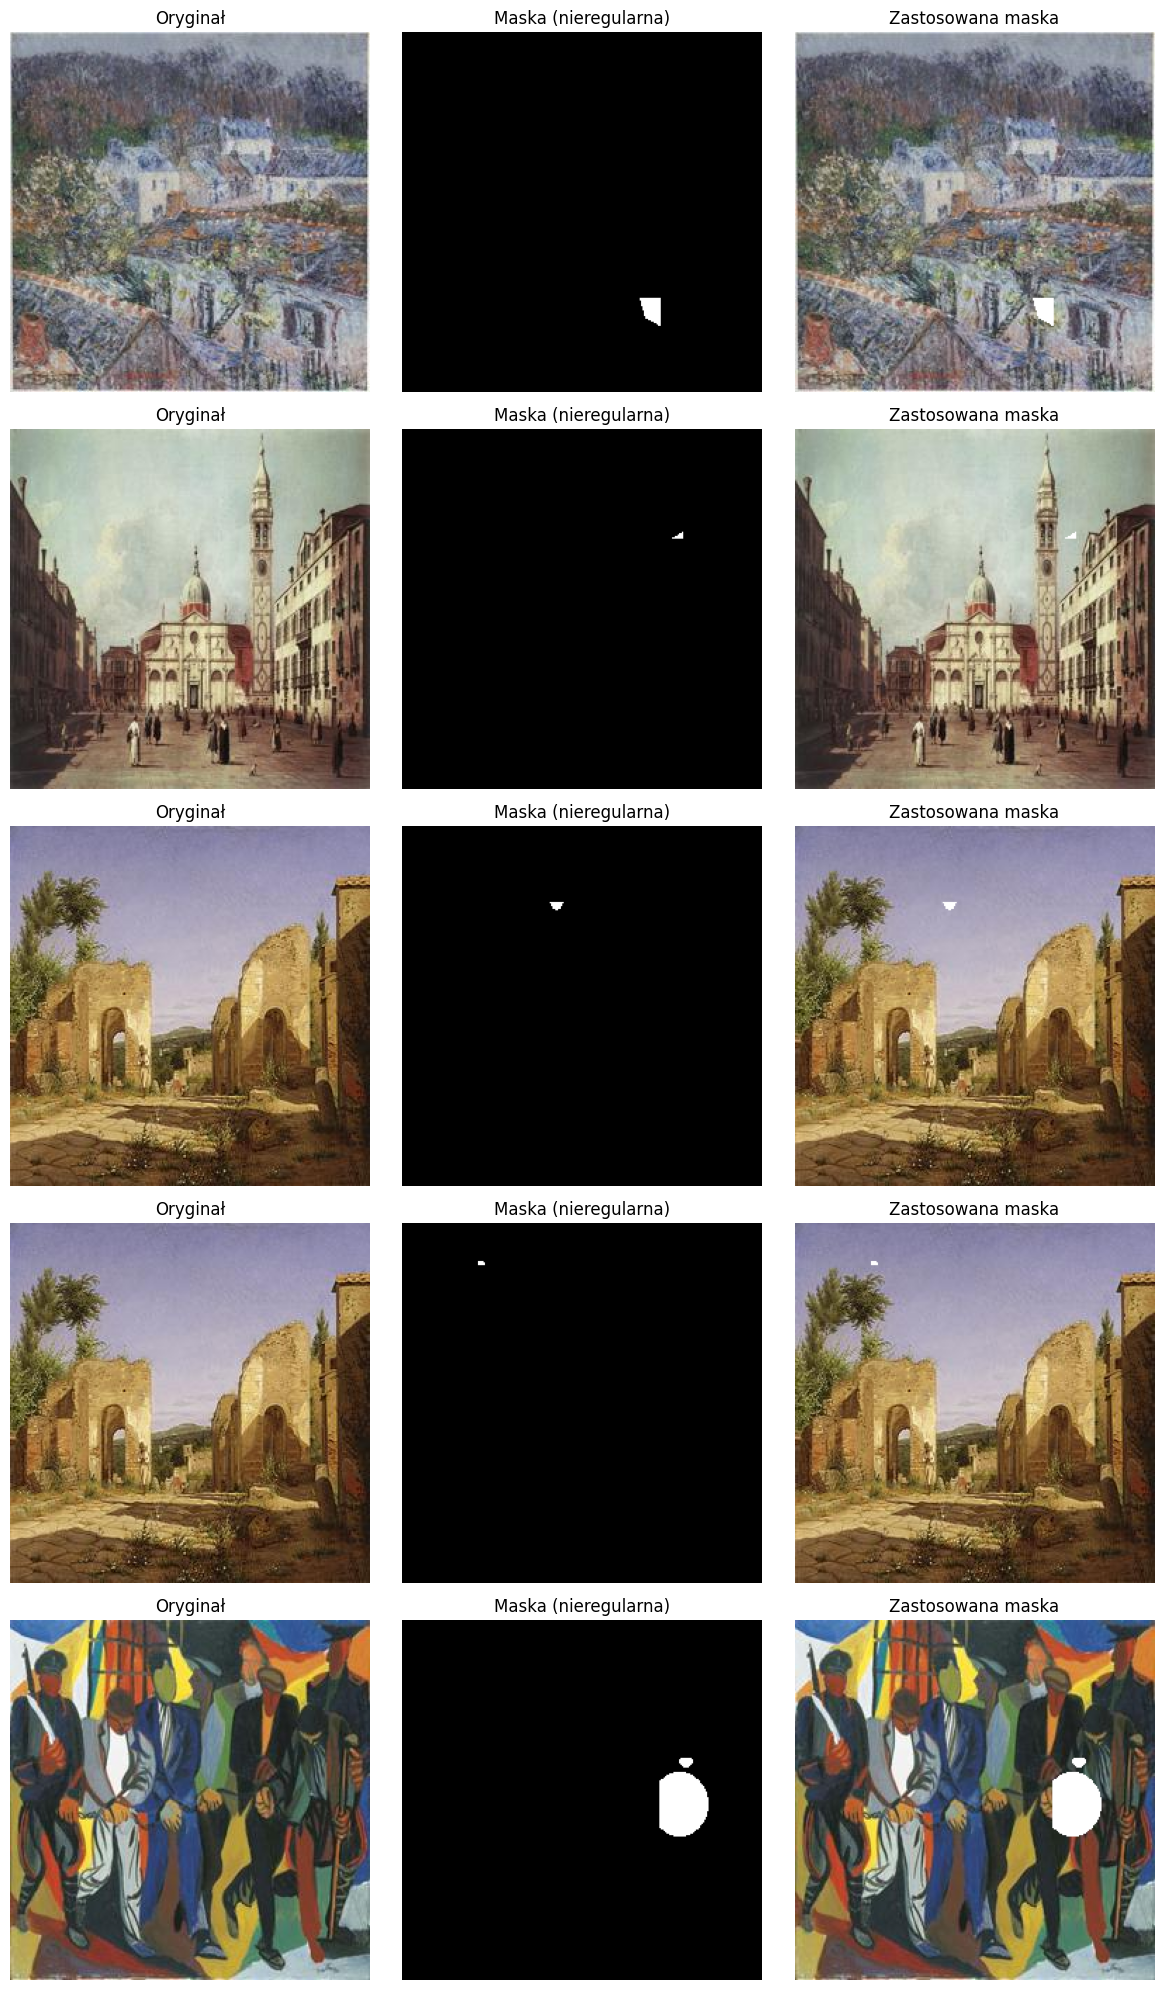

Gotowe — wygenerowano nieregularne maski o maksymalnej powierzchni 6% obrazu


In [5]:
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
import random
from datasets import load_dataset
from PIL import Image, ImageDraw

# --- Ustawienia ---
SAMPLE_PERCENT = "train[:0.5%]"  # mała próbka; zmień jeśli potrzeba
NUM_EXAMPLES = 5  # ile obrazów pokazać
IMG_SIZE = (256, 256)
MAX_MASK_FRACTION = 1/16  # maksymalna powierzchnia maski

# 1. Wczytanie małej próbki zbioru WikiArt z Hugging Face
print("Wczytywanie małej próbki WikiArt (może chwilę potrwać)...")
dataset = load_dataset("Artificio/WikiArt_Full")["train"]
dataset = dataset.shuffle(seed=42).select(range(50))  # pobiera np. 50 losowych obrazów

transform = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToTensor()
])

def get_random_image():
    sample = random.choice(dataset)
    img = sample['image'].convert('RGB')
    return transform(img)

# 2. Generowanie nieregularnej maski (złożonej z losowych elips/poligonów)
def generate_irregular_mask(shape, max_fraction=MAX_MASK_FRACTION, max_elements=30):
    """Zwraca maskę binarną torch.Tensor o kształcie (1, H, W).

    Algorytm: rysujemy kolejne wypełnione elipsy/polygony na obrazie-mask, dopóki
    nie osiągniemy docelowej powierzchni (<= max_fraction * obrazu).
    """
    _, h, w = shape
    max_area = int(h * w * max_fraction)

    # Startujemy z pustą maską PIL
    mask_img = Image.new('L', (w, h), 0)
    draw = ImageDraw.Draw(mask_img)

    current_area = 0
    attempts = 0

    while current_area < max_area and attempts < max_elements:
        attempts += 1
        # losowy kształt: elipsa lub nieregularny wielokąt
        shape_type = random.choice(['ellipse', 'polygon'])

        if shape_type == 'ellipse':
            # wielkość elipsy ograniczona, aby pojedynczy element nie był za duży
            max_h = int(h * random.uniform(0.05, 0.25))
            max_w = int(w * random.uniform(0.05, 0.25))
            eh = random.randint(int(max(3, max_h*0.3)), max(3, max_h))
            ew = random.randint(int(max(3, max_w*0.3)), max(3, max_w))
            top = random.randint(0, h - eh)
            left = random.randint(0, w - ew)
            bbox = [left, top, left + ew, top + eh]
            draw.ellipse(bbox, fill=255)
        else:
            # polygon: kilka punktów w okolicy środka
            center_x = random.randint(0, w)
            center_y = random.randint(0, h)
            num_points = random.randint(3, 8)
            radius_x = int(w * random.uniform(0.02, 0.18))
            radius_y = int(h * random.uniform(0.02, 0.18))
            points = []
            for k in range(num_points):
                angle = 2 * np.pi * k / num_points + random.uniform(-0.5, 0.5)
                rx = int(center_x + np.cos(angle) * random.uniform(0.3, 1.0) * radius_x)
                ry = int(center_y + np.sin(angle) * random.uniform(0.3, 1.0) * radius_y)
                # upewnij się, że punkty są w granicach obrazu
                rx = max(0, min(w-1, rx))
                ry = max(0, min(h-1, ry))
                points.append((rx, ry))
            draw.polygon(points, fill=255)

        # policz aktualną powierzchnię
        np_mask = np.array(mask_img) > 0
        current_area = np_mask.sum()

        # jeśli przekroczyliśmy dozwoloną powierzchnię, odwołaj ostatni rysunek
        if current_area > max_area:
            # Najprostsze rozwiązanie: usuń ostatni dodany element przez ponowne rysowanie
            # — musimy przywrócić maskę bez ostatniego elementu. Proste podejście: resetuj
            # i rysuj od początku ale o jeden mniejszą liczbę prób.
            # W praktyce, aby uniknąć komplikacji, zatrzymujemy pętlę i usuniemy nadmiar
            break

    # Jeśli przekroczono max_area, przytnij maskę losowym prostokątem tak by spełniała warunek
    np_mask = np.array(mask_img) > 0
    if np_mask.sum() > max_area:
        # stwórz prostokąt przycinający (losowo) - wyzeruj piksele poza wybranym prostokątem
        # aż uzyskamy limit. Prostsza metoda: znajdź losowy prostokąt i przecięcie
        for _ in range(50):
            ph = random.randint(1, h//4)
            pw = random.randint(1, w//4)
            top = random.randint(0, h - ph)
            left = random.randint(0, w - pw)
            crop = np.zeros_like(np_mask)
            crop[top:top+ph, left:left+pw] = True
            new_mask = np_mask & crop
            if new_mask.sum() <= max_area and new_mask.sum() > 0:
                np_mask = new_mask
                break
        # jeśli nadal za duża, wykonaj proste cięcie od góry
        if np_mask.sum() > max_area:
            flat = np_mask.flatten()
            # indeksy posortowane według losowego permuted order
            idx = np.random.permutation(flat.size)
            keep = np.zeros_like(flat, dtype=bool)
            keep[idx[:max_area]] = True
            flat = keep
            np_mask = flat.reshape(h, w)

    mask_tensor = torch.from_numpy(np_mask.astype(np.float32)).unsqueeze(0)
    return mask_tensor

# 3. Nakładanie maski (mask=1 => uszkodzenie). Zostawiamy maskę jako oddzielny tensor.
def apply_mask(img, mask, fill_value=1.0):
    damaged = img.clone()
    damaged = damaged * (1 - mask) + fill_value * mask
    return damaged

# 4. Demonstracja na kilku przykładowych obrazach
fig, axes = plt.subplots(NUM_EXAMPLES, 3, figsize=(12, 4 * NUM_EXAMPLES))
for i in range(NUM_EXAMPLES):
    img = get_random_image()
    mask = generate_irregular_mask(img.shape)
    damaged = apply_mask(img, mask)

    ax0 = axes[i, 0] if NUM_EXAMPLES > 1 else axes[0]
    ax1 = axes[i, 1] if NUM_EXAMPLES > 1 else axes[1]
    ax2 = axes[i, 2] if NUM_EXAMPLES > 1 else axes[2]

    ax0.imshow(img.permute(1, 2, 0))
    ax0.set_title('Oryginał')
    ax0.axis('off')

    ax1.imshow(mask.squeeze(), cmap='gray')
    ax1.set_title('Maska (nieregularna)')
    ax1.axis('off')

    ax2.imshow(damaged.permute(1, 2, 0))
    ax2.set_title('Zastosowana maska')
    ax2.axis('off')

plt.tight_layout()
plt.show()

print('Gotowe — wygenerowano nieregularne maski o maksymalnej powierzchni {}% obrazu'.format(int(MAX_MASK_FRACTION*100)))


Wczytywanie małej próbki WikiArt (może chwilę potrwać)...


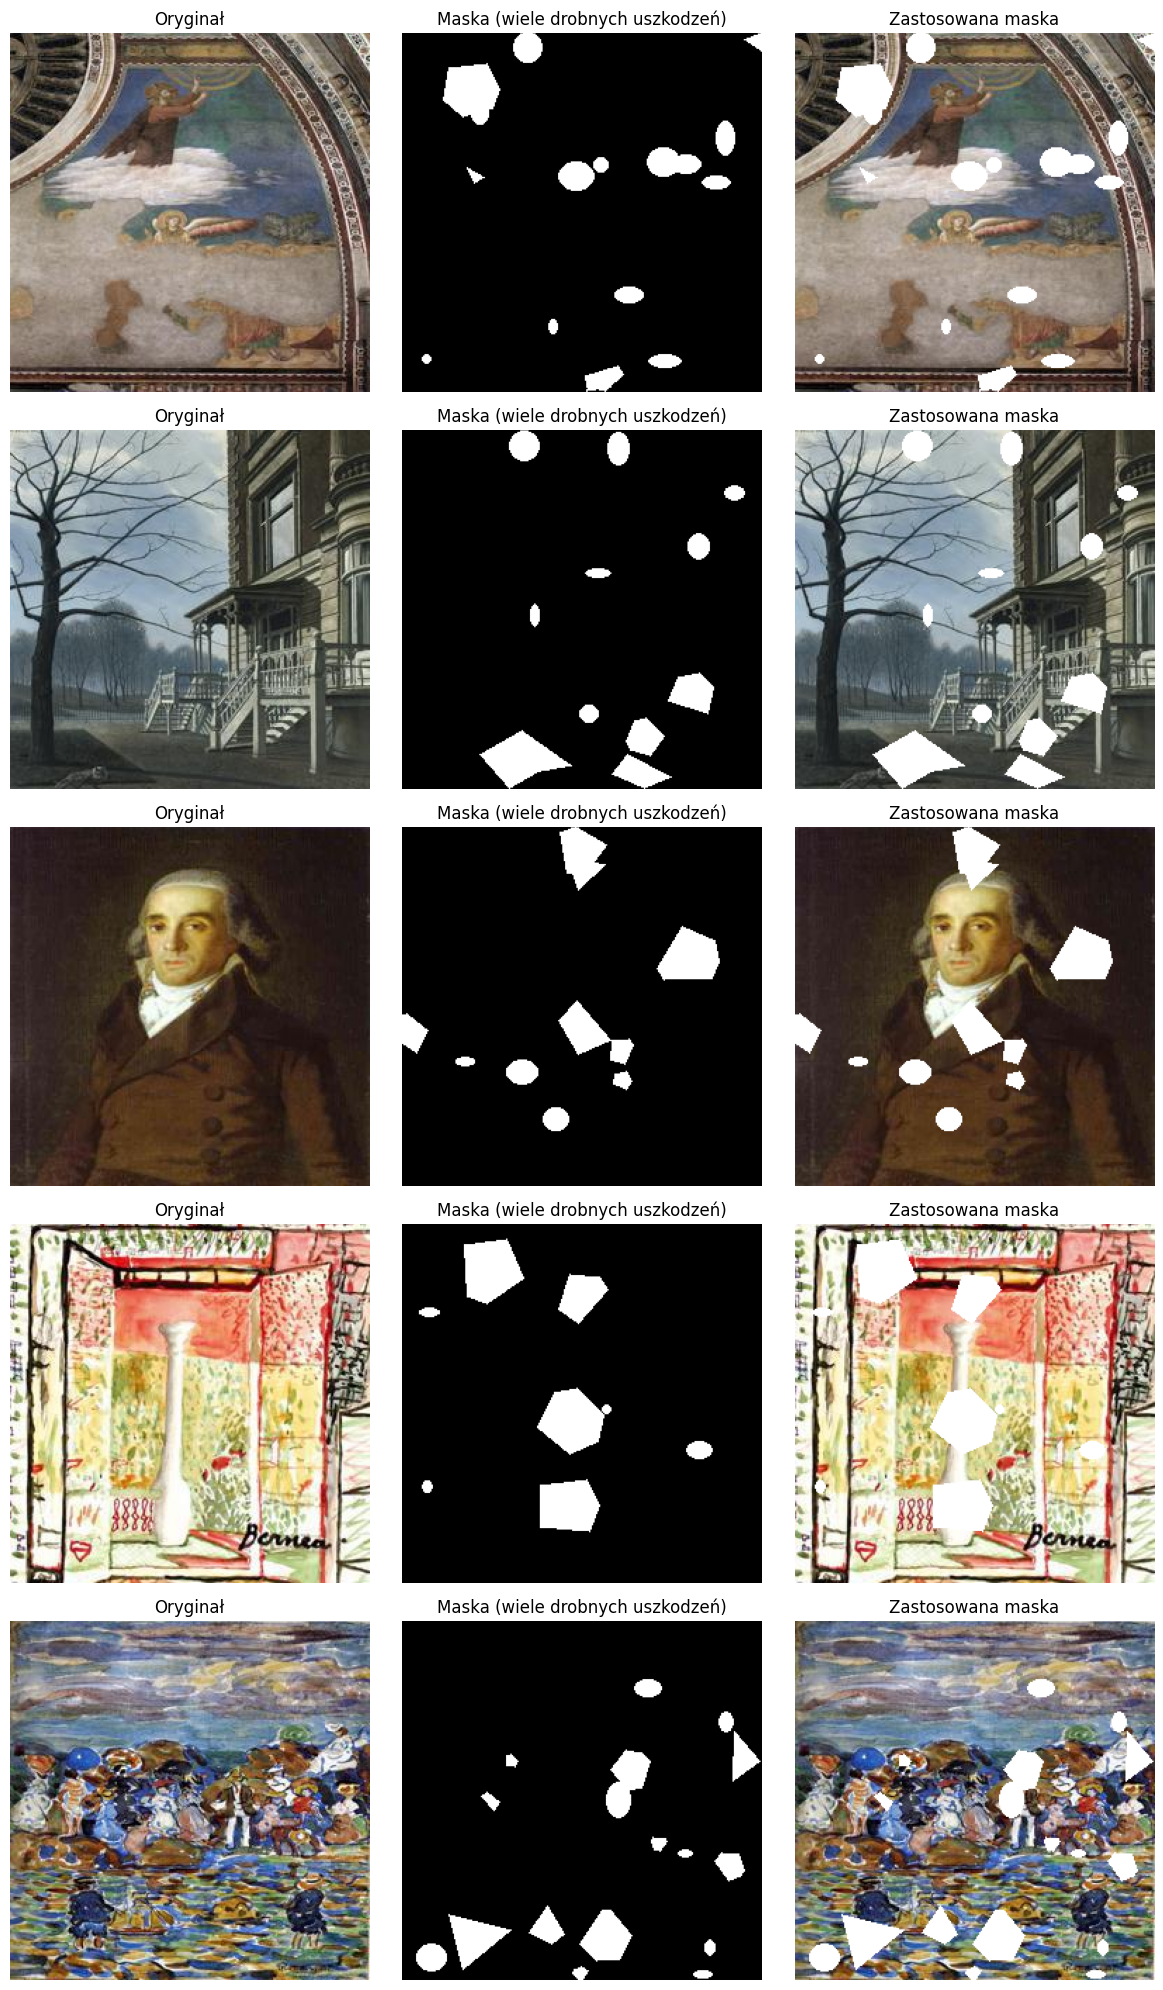

In [9]:
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
import random
from datasets import load_dataset
from PIL import Image, ImageDraw

# --- Ustawienia ---
NUM_EXAMPLES = 5  # ile obrazów pokazać
IMG_SIZE = (256, 256)
MAX_MASK_FRACTION = 1/16  # maksymalna łączna powierzchnia uszkodzeń
NUM_DAMAGE_ELEMENTS = 50  # liczba drobnych uszkodzeń na obrazie

# 1. Wczytanie zbioru WikiArt z Hugging Face
print("Wczytywanie małej próbki WikiArt (może chwilę potrwać)...")
dataset = load_dataset("Artificio/WikiArt_Full")["train"]
dataset = dataset.shuffle(seed=42).select(range(50))  # mała próbka

transform = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToTensor()
])

def get_random_image():
    sample = random.choice(dataset)
    img = sample['image'].convert('RGB')
    return transform(img)

# 2. Generowanie maski z wieloma małymi nieregularnymi uszkodzeniami
def generate_irregular_mask(shape, max_fraction=MAX_MASK_FRACTION, num_elements=NUM_DAMAGE_ELEMENTS):
    _, h, w = shape
    max_area = int(h * w * max_fraction)

    mask_img = Image.new('L', (w, h), 0)
    draw = ImageDraw.Draw(mask_img)

    total_area = 0
    for _ in range(num_elements):
        # losowy kształt (mały): elipsa lub poligon
        shape_type = random.choice(['ellipse', 'polygon'])

        if shape_type == 'ellipse':
            eh = random.randint(5, 25)
            ew = random.randint(5, 25)
            top = random.randint(0, h - eh)
            left = random.randint(0, w - ew)
            draw.ellipse([left, top, left + ew, top + eh], fill=255)
        else:
            cx = random.randint(0, w)
            cy = random.randint(0, h)
            num_points = random.randint(3, 6)
            r = random.randint(5, 25)
            points = []
            for k in range(num_points):
                angle = 2 * np.pi * k / num_points + random.uniform(-0.5, 0.5)
                rx = int(cx + np.cos(angle) * r)
                ry = int(cy + np.sin(angle) * r)
                rx = max(0, min(w-1, rx))
                ry = max(0, min(h-1, ry))
                points.append((rx, ry))
            draw.polygon(points, fill=255)

        # sprawdzanie łącznej powierzchni
        np_mask = np.array(mask_img) > 0
        total_area = np_mask.sum()
        if total_area > max_area:
            break

    mask_tensor = torch.from_numpy((np.array(mask_img) > 0).astype(np.float32)).unsqueeze(0)
    return mask_tensor

# 3. Nakładanie maski
def apply_mask(img, mask, fill_value=1.0):
    return img * (1 - mask) + fill_value * mask

# 4. Wizualizacja
fig, axes = plt.subplots(NUM_EXAMPLES, 3, figsize=(12, 4 * NUM_EXAMPLES))
for i in range(NUM_EXAMPLES):
    img = get_random_image()
    mask = generate_irregular_mask(img.shape)
    damaged = apply_mask(img, mask)

    ax0 = axes[i, 0] if NUM_EXAMPLES > 1 else axes[0]
    ax1 = axes[i, 1] if NUM_EXAMPLES > 1 else axes[1]
    ax2 = axes[i, 2] if NUM_EXAMPLES > 1 else axes[2]

    ax0.imshow(img.permute(1, 2, 0))
    ax0.set_title('Oryginał')
    ax0.axis('off')

    ax1.imshow(mask.squeeze(), cmap='gray')
    ax1.set_title('Maska (wiele drobnych uszkodzeń)')
    ax1.axis('off')

    ax2.imshow(damaged.permute(1, 2, 0))
    ax2.set_title('Zastosowana maska')
    ax2.axis('off')

plt.tight_layout()
plt.show()

Wczytywanie małej próbki WikiArt (może chwilę potrwać)...


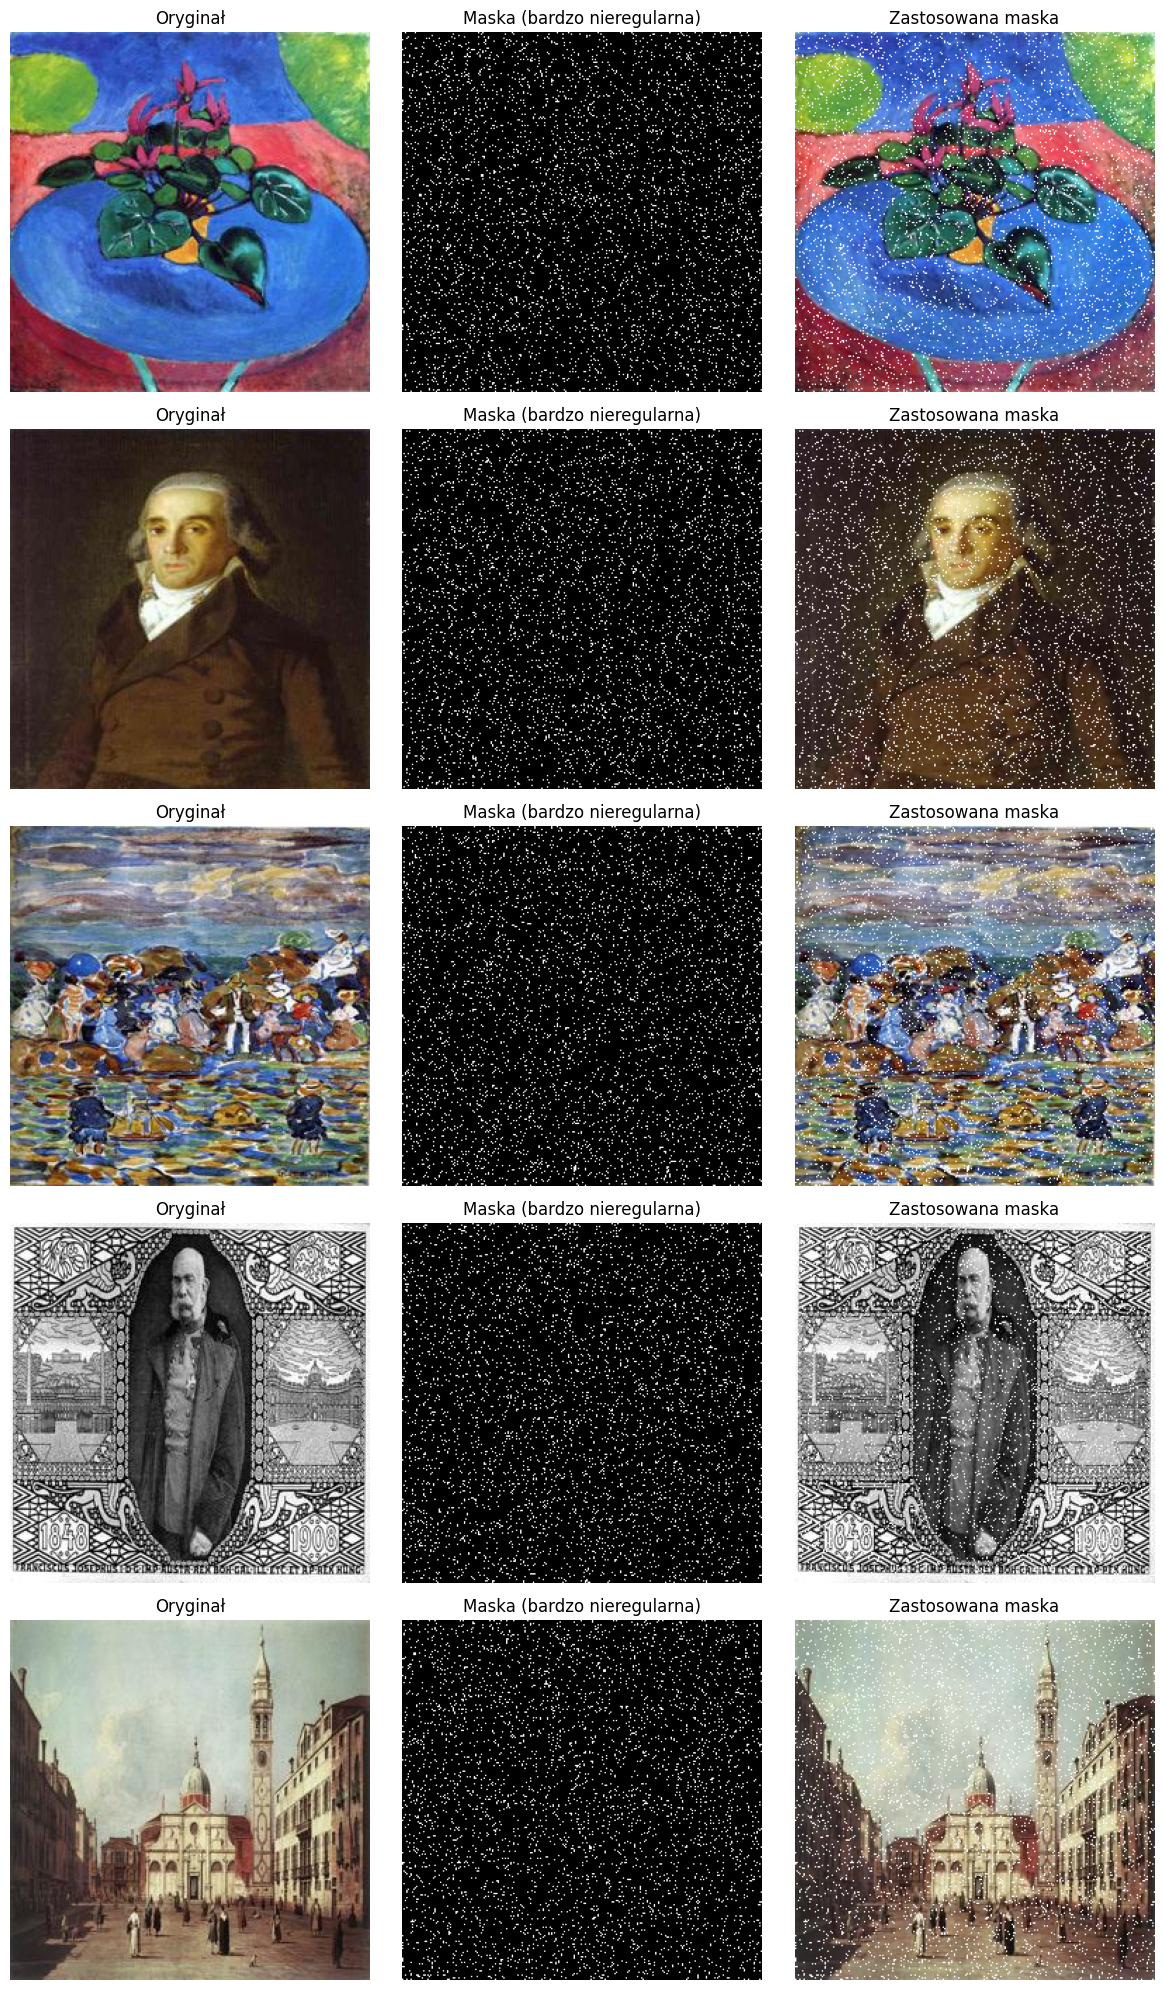

In [12]:
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
import random
from datasets import load_dataset
from PIL import Image, ImageDraw, ImageFilter

# --- Ustawienia ---
NUM_EXAMPLES = 5  # ile obrazów pokazać
IMG_SIZE = (256, 256)
MAX_MASK_FRACTION = 1/16  # maksymalna łączna powierzchnia uszkodzeń
NUM_DAMAGE_ELEMENTS = 60  # liczba nieregularnych uszkodzeń

# 1. Wczytanie zbioru WikiArt z Hugging Face
print("Wczytywanie małej próbki WikiArt (może chwilę potrwać)...")
dataset = load_dataset("Artificio/WikiArt_Full")["train"]
dataset = dataset.shuffle(seed=42).select(range(50))  # mała próbka

transform = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToTensor()
])

def get_random_image():
    sample = random.choice(dataset)
    img = sample['image'].convert('RGB')
    return transform(img)

# 2. Generowanie bardziej nieregularnych masek (połączenie kształtów + blur + szum)
def generate_irregular_mask(shape, max_fraction=MAX_MASK_FRACTION, num_elements=NUM_DAMAGE_ELEMENTS):
    _, h, w = shape
    max_area = int(h * w * max_fraction)

    mask_img = Image.new('L', (w, h), 0)
    draw = ImageDraw.Draw(mask_img)

    for _ in range(num_elements):
        # losowy nieregularny kształt bazujący na zniekształconym wielokącie
        cx = random.randint(0, w)
        cy = random.randint(0, h)
        num_points = random.randint(5, 10)
        r = random.randint(10, 40)
        irregularity = random.uniform(0.3, 1.5)

        points = []
        for k in range(num_points):
            angle = 2 * np.pi * k / num_points + random.uniform(-irregularity, irregularity)
            rx = int(cx + np.cos(angle) * r * random.uniform(0.4, 1.2))
            ry = int(cy + np.sin(angle) * r * random.uniform(0.4, 1.2))
            rx = max(0, min(w-1, rx))
            ry = max(0, min(h-1, ry))
            points.append((rx, ry))

        draw.polygon(points, fill=255)

        np_mask = np.array(mask_img) > 0
        if np_mask.sum() > max_area:
            break

    # Dodaj delikatny blur i prógowanie, by uzyskać bardziej organiczne kształty
    mask_img = mask_img.filter(ImageFilter.GaussianBlur(radius=3))
    np_mask = np.array(mask_img) / 255.0

    # dodaj losowy szum do maski i prógowanie
    noise = np.random.rand(h, w) * 0.3
    np_mask = np.clip(np_mask + noise, 0, 1)
    np_mask = (np_mask > 0.5).astype(np.float32)

    # ogranicz powierzchnię jeśli przekroczono limit
    flat = np_mask.flatten()
    if flat.sum() > max_area:
        idx = np.random.permutation(flat.size)
        keep = np.zeros_like(flat)
        keep[idx[:max_area]] = 1
        np_mask = keep.reshape(h, w)

    mask_tensor = torch.from_numpy(np_mask).unsqueeze(0)
    return mask_tensor

# 3. Nakładanie maski
def apply_mask(img, mask, fill_value=1.0):
    return img * (1 - mask) + fill_value * mask

# 4. Wizualizacja
fig, axes = plt.subplots(NUM_EXAMPLES, 3, figsize=(12, 4 * NUM_EXAMPLES))
for i in range(NUM_EXAMPLES):
    img = get_random_image()
    mask = generate_irregular_mask(img.shape)
    damaged = apply_mask(img, mask)

    ax0 = axes[i, 0] if NUM_EXAMPLES > 1 else axes[0]
    ax1 = axes[i, 1] if NUM_EXAMPLES > 1 else axes[1]
    ax2 = axes[i, 2] if NUM_EXAMPLES > 1 else axes[2]

    ax0.imshow(img.permute(1, 2, 0))
    ax0.set_title('Oryginał')
    ax0.axis('off')

    ax1.imshow(mask.squeeze(), cmap='gray')
    ax1.set_title('Maska (bardzo nieregularna)')
    ax1.axis('off')

    ax2.imshow(damaged.permute(1, 2, 0))
    ax2.set_title('Zastosowana maska')
    ax2.axis('off')

plt.tight_layout()
plt.show()